In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/wait_times.csv")
df.shape



(2604, 6)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2604 entries, 0 to 2603
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   port_name     2604 non-null   str    
 1   category      2604 non-null   str    
 2   lane_type     2604 non-null   str    
 3   status        2604 non-null   str    
 4   wait_minutes  1284 non-null   float64
 5   timestamp     2604 non-null   str    
dtypes: float64(1), str(5)
memory usage: 122.2 KB


In [21]:
df.head()


,port_name,category,lane_type,status,wait_minutes,timestamp
0,Bridge of the Americas,Commercial Vehicles,General,closed,NaN,2026-08-09 15:26:14.176934
1,Bridge of the Americas,Commercial Vehicles,Fast,closed,NaN,2026-08-09 15:26:14.176934
2,Bridge of the Americas,Passenger Vehicles,General,reported,50.0,2026-08-09 15:26:14.176934
3,Bridge of the Americas,Passenger Vehicles,Sentri,not applicable,NaN,2026-08-09 15:26:14.176934
4,Bridge of the Americas,Passenger Vehicles,Ready,reported,45.0,2026-08-09 15:26:14.176934


In [22]:
df.status.value_counts()

status
reported          1284
not applicable     837
closed             483
Name: count, dtype: int64

Timestamp Conversion

In [23]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df.timestamp.dt.hour
df["day_of_week"] = df.timestamp.dt.day_name()
df.head()

,port_name,category,lane_type,status,wait_minutes,timestamp,hour,day_of_week
0,Bridge of the Americas,Commercial Vehicles,General,closed,NaN,2026-08-09 15:26:14.176934,15,Sunday
1,Bridge of the Americas,Commercial Vehicles,Fast,closed,NaN,2026-08-09 15:26:14.176934,15,Sunday
2,Bridge of the Americas,Passenger Vehicles,General,reported,50.0,2026-08-09 15:26:14.176934,15,Sunday
3,Bridge of the Americas,Passenger Vehicles,Sentri,not applicable,NaN,2026-08-09 15:26:14.176934,15,Sunday
4,Bridge of the Americas,Passenger Vehicles,Ready,reported,45.0,2026-08-09 15:26:14.176934,15,Sunday


Reported by Hour

In [24]:
reported = df[df.status == "reported"]
avg_by_hour_report = reported.groupby(["port_name", "hour"]).wait_minutes.mean()
avg_by_hour_report

port_name               hour
Bridge of the Americas  0       37.142857
                        2       46.555556
                        3       36.777778
                        4       32.875000
                        5       26.384615
                                  ...    
Ysleta                  19      24.484848
                        20      22.666667
                        21      23.387097
                        22      22.129032
                        23      21.483871
Name: wait_minutes, Length: 64, dtype: float64

Non-Missing Hour Times

In [25]:
reported.groupby("port_name").hour.nunique()

port_name
Bridge of the Americas    16
Paso Del Norte            16
Stanton                   16
Ysleta                    16
Name: hour, dtype: int64

In [26]:
sorted(reported.hour.unique())

[np.int32(0),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(12),
 np.int32(14),
 np.int32(15),
 np.int32(16),
 np.int32(17),
 np.int32(18),
 np.int32(19),
 np.int32(20),
 np.int32(21),
 np.int32(22),
 np.int32(23)]

In [27]:
df[df.hour.isin([1, 6, 7, 8, 9, 10, 11, 13])].status.value_counts()

Series([], Name: count, dtype: int64)

In [28]:
df[df.hour.isin([1, 6, 7, 8, 9, 10, 11, 13])].timestamp.dt.date.value_counts()

Series([], Name: count, dtype: int64)

Hour Chart

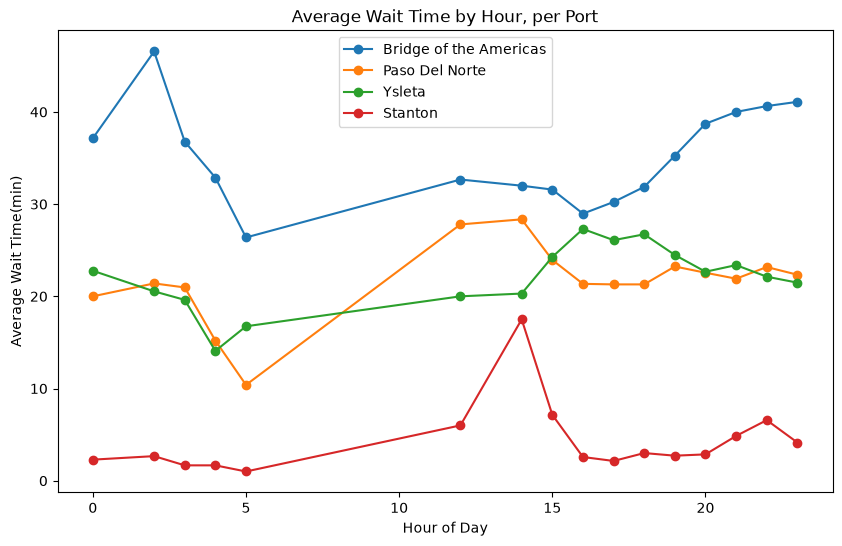

In [29]:
fig, ax = plt.subplots(figsize=(10,6))

for port in reported.port_name.unique():
    port_data = avg_by_hour_report[port]
    ax.plot(port_data.index, port_data.values, marker='o', label=port)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Wait Time(min)")
ax.set_title("Average Wait Time by Hour, per Port")
ax.legend()
plt.show()

In [52]:
fig.savefig("../figures/average_hour_wait_time_per_port", dpi=150, bbox_inches="tight")

In [30]:
counts = reported.groupby(["port_name", "hour"]).wait_minutes.count().unstack()
counts

hour,0,2,3,4,5,12,14,15,16,17,18,19,20,21,22,23
port_name,,,,,,,,,,,,,,,,
Bridge of the Americas,21,9,18,8,13,3,13,26,30,30,31,27,25,23,22,21
Paso Del Norte,35,15,28,10,23,5,20,35,34,34,34,34,34,34,34,35
Stanton,7,3,6,3,6,1,4,7,7,7,7,7,7,7,7,7
Ysleta,31,13,26,13,28,5,20,33,33,33,33,33,33,31,31,31


**Data quality note:** hours 2-5 and 12 have notably fewer readings across all ports
(likely due to an early scraper bug, since fixed) and should be treated as lower-confidence.
Stanton has consistently fewer readings than the other three ports throughout the week.

In [59]:
avg_time = reported.groupby("port_name").wait_minutes.mean()
avg_time.sort_values()

port_name
Stanton                    4.010753
Paso Del Norte            21.596847
Ysleta                    22.761124
Bridge of the Americas    34.884375
Name: wait_minutes, dtype: float64

Reported by Day

In [48]:
avg_by_day_report = reported.groupby(["port_name", "day_of_week"]).wait_minutes.mean()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_day_report = avg_by_day_report.reindex(day_order, level="day_of_week")
avg_by_day_report


port_name               day_of_week
Bridge of the Americas  Monday         35.666667
                        Tuesday        37.021739
                        Wednesday      34.714286
                        Thursday       30.100000
                        Friday         30.000000
                        Saturday       39.047619
                        Sunday         37.510638
Paso Del Norte          Monday         24.423729
                        Tuesday        22.500000
                        Wednesday      20.275362
                        Thursday       14.140625
                        Friday         14.546875
                        Saturday       26.122807
                        Sunday         30.063492
Stanton                 Monday          4.500000
                        Tuesday         5.071429
                        Wednesday       4.214286
                        Thursday        2.153846
                        Friday          6.769231
                        Saturday 

Day Chart

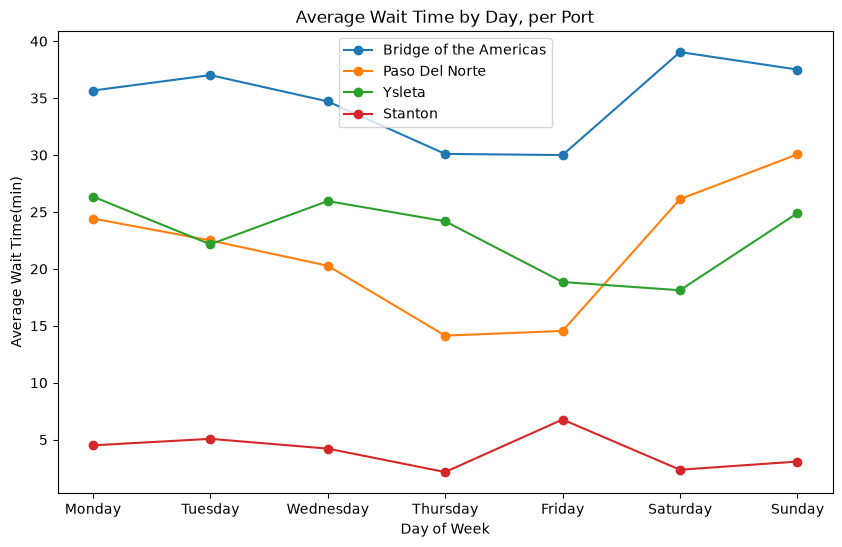

In [54]:
fig, ax = plt.subplots(figsize=(10,6))

for port in reported.port_name.unique():
    port_data = avg_by_day_report[port]
    ax.plot(port_data.index, port_data.values, marker='o', label=port)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Wait Time(min)")
ax.set_title("Average Wait Time by Day, per Port")
ax.legend()
plt.show()

In [55]:
fig.savefig("../figures/average_day_wait_time_per_port", dpi=150, bbox_inches="tight")

How many Sentri/Ready lanes are open while the General Lane is closed?

In [6]:
lanes = df[(df.category == 'Passenger Vehicles') & (df.lane_type.isin(['Sentri', 'General', 'Ready']))]
lanes

,port_name,category,lane_type,status,wait_minutes,timestamp,hour,day_of_week
2,Bridge of the Americas,Passenger Vehicles,General,reported,50.0,2026-08-09 15:26:14.176934,15,Sunday
3,Bridge of the Americas,Passenger Vehicles,Sentri,not applicable,NaN,2026-08-09 15:26:14.176934,15,Sunday
4,Bridge of the Americas,Passenger Vehicles,Ready,reported,45.0,2026-08-09 15:26:14.176934,15,Sunday
9,Paso Del Norte,Passenger Vehicles,General,reported,54.0,2026-08-09 15:26:14.176934,15,Sunday
10,Paso Del Norte,Passenger Vehicles,Sentri,reported,5.0,2026-08-09 15:26:14.176934,15,Sunday
...,...,...,...,...,...,...,...,...
2593,Ysleta,Passenger Vehicles,Sentri,reported,15.0,2026-08-16 04:23:54.417784,4,Sunday
2594,Ysleta,Passenger Vehicles,Ready,reported,70.0,2026-08-16 04:23:54.417784,4,Sunday
2599,Stanton,Passenger Vehicles,General,closed,NaN,2026-08-16 04:23:54.417784,4,Sunday
2600,Stanton,Passenger Vehicles,Sentri,reported,1.0,2026-08-16 04:23:54.417784,4,Sunday


In [7]:
lanes_wide = lanes.pivot(index=['port_name', 'timestamp'], columns='lane_type', values='status')
lanes_wide

lane_type                                           General     Ready  \
port_name              timestamp                                        
Bridge of the Americas 2026-08-09 15:26:14.176934  reported  reported   
                       2026-08-09 16:19:22.336910  reported  reported   
                       2026-08-09 17:19:54.172436  reported  reported   
                       2026-08-09 18:21:26.525818  reported  reported   
                       2026-08-09 19:23:16.904361  reported  reported   
...                                                     ...       ...   
Ysleta                 2026-08-15 23:09:41.198493    closed  reported   
                       2026-08-16 00:31:50.179399    closed  reported   
                       2026-08-16 02:14:14.694061    closed  reported   
                       2026-08-16 03:37:25.119384    closed  reported   
                       2026-08-16 04:23:54.417784    closed  reported   

lane_type                                                  Sentri  
port_name              timestamp                                   
Bridge of the Americas 2026-08-09 15:26:14.176934  not applicable  
                       2026-08-09 16:19:22.336910  not applicable  
                       2026-08-09 17:19:54.172436  not applicable  
                       2026-08-09 18:21:26.525818  not applicable  
                       2026-08-09 19:23:16.904361  not applicable  
...                                                           ...  
Ysleta                 2026-08-15 23:09:41.198493        reported  
                       2026-08-16 00:31:50.179399        reported  
                       2026-08-16 02:14:14.694061        reported  
                       2026-08-16 03:37:25.119384        reported  
                       2026-08-16 04:23:54.417784        reported  

[372 rows x 3 columns]

In [8]:
compare_lanes = lanes_wide[~lanes_wide['General'].str.contains('reported')] 
compare_lanes = compare_lanes[compare_lanes['Sentri'].str.contains('reported') | compare_lanes['Ready'].str.contains('reported')]
compare_lanes

lane_type                            General           Ready    Sentri
port_name timestamp                                                   
Stanton   2026-08-09 15:26:14.176934  closed  not applicable  reported
          2026-08-09 16:19:22.336910  closed  not applicable  reported
          2026-08-09 17:19:54.172436  closed  not applicable  reported
          2026-08-09 18:21:26.525818  closed  not applicable  reported
          2026-08-09 19:23:16.904361  closed  not applicable  reported
...                                      ...             ...       ...
Ysleta    2026-08-15 23:09:41.198493  closed        reported  reported
          2026-08-16 00:31:50.179399  closed        reported  reported
          2026-08-16 02:14:14.694061  closed        reported  reported
          2026-08-16 03:37:25.119384  closed        reported  reported
          2026-08-16 04:23:54.417784  closed        reported  reported

[186 rows x 3 columns]

In [60]:
pct = len(compare_lanes) / len(lanes_wide) * 100
pct

50.0

In [61]:
compare_lanes.groupby('port_name').size()

port_name
Stanton    93
Ysleta     93
dtype: int64

In [66]:
compare_lanes.groupby("port_name").size()

port_name
Stanton    93
Ysleta     93
dtype: int64

In [15]:
closure_rate = lanes_wide.reset_index().groupby('port_name').apply(
    lambda g: (g.General =="closed").mean() * 100
)
closure_rate

port_name
Bridge of the Americas      2.150538
Paso Del Norte              0.000000
Stanton                   100.000000
Ysleta                    100.000000
dtype: float64

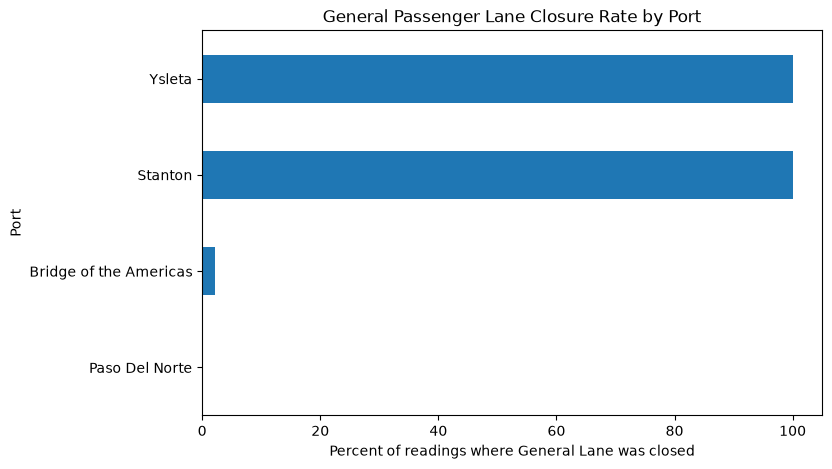

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
closure_rate.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Percent of readings where General Lane was closed")
ax.set_ylabel("Port")
ax.set_title("General Passenger Lane Closure Rate by Port")
plt.show()

In [60]:
fig.savefig("../figures/general_lane_closure_by_port.png", dpi=150, bbox_inches="tight")

## Findings

- **Fastest bridge:** Stanton ~ four minute average per day
- **Slowest bridge:** Bridge of the Americas ~ 35 minute average per day
- **Hour-of-day pattern:** Bridge of the Americas is consistently the slowest 
  crossing throughout the day, while Stanton is consistently fastest. 
  Paso Del Norte and Ysleta cross paths around midday.
- **Day-of-week pattern:** Same pattern as the hourly average, with Ysleta and Paso Del Norte sometimes
  crossing throughout the week.
- **General lane closures:** At Stanton and Ysleta, the General (non-trusted-traveler) 
  passenger lane was closed in 93 out of 93 collected readings (100%) — every single 
  time data was collected. Bridge of the Americas and Paso Del Norte showed this 
  almost never. This suggests these two ports may be routing all general public 
  traffic through alternate lanes/procedures not reflected in the standard 
  wait-time categories, or genuinely operate without a staffed general lane.

## Data quality notes
- Hours 2-5 and 12 have fewer readings across all ports due to an early scraper 
  bug (handling of CBP's "Pending" status), fixed August 15. Treat these hours as 
  lower-confidence.
- Stanton has fewer readings than the other three ports throughout the week.